# Demand Forecasting

Forecast daily SKU-region demand with a seasonal-naive baseline and XGBoost using a chronological split.

In [7]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
forecast_data = pd.read_csv(PROJECT_ROOT / "data/processed/forecast_dataset.csv", parse_dates=["date"])
print(forecast_data.shape)
display(forecast_data.head())

(53400, 21)


,date,sku,region,units_sold,price,promotion,is_holiday,year,month,week,...,day_of_year,is_weekend,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14,rolling_mean_28,rolling_std_28
0,2023-01-29,BB1000,Central,458,55.0,0,0,2023,1,4,...,29,1,371.0,506.0,437.0,432.0,411.285714,391.142857,386.071429,50.329234
1,2023-01-30,BB1000,Central,312,55.0,0,0,2023,1,5,...,30,0,458.0,402.0,366.0,327.0,404.428571,392.642857,387.000000,51.435684
2,2023-01-31,BB1000,Central,351,55.0,0,0,2023,1,5,...,31,0,312.0,376.0,348.0,451.0,391.571429,388.785714,386.464286,52.156802
3,2023-02-01,BB1000,Central,385,55.0,0,0,2023,2,5,...,32,0,351.0,331.0,371.0,363.0,388.000000,389.000000,382.892857,50.984630
4,2023-02-02,BB1000,Central,348,55.0,0,0,2023,2,5,...,33,0,385.0,479.0,292.0,357.0,395.714286,390.000000,383.678571,50.836013


In [9]:
forecasts = pd.read_csv(PROJECT_ROOT / "data/processed/demand_forecasts.csv", parse_dates=["date"])
performance = pd.read_csv(PROJECT_ROOT / "data/processed/forecast_performance_by_sku.csv")
display(forecasts.head())
display(performance.sort_values("WAPE"))

,date,sku,region,units_sold,ml_prediction,forecast_error,promotion,is_holiday
0,2025-07-01,BB1000,Central,529,513.78140,15.218628,0,0
1,2025-07-01,BB1000,East,534,532.53705,1.462952,0,0
2,2025-07-01,BB1000,North,643,583.10486,59.895142,0,0
3,2025-07-01,BB1000,South,775,652.10864,122.891357,0,0
4,2025-07-01,BB1000,West,640,692.52484,-52.524841,0,0


,sku,actual_demand,forecast_demand,MAE,WAPE
0,OR1000,400939,399835.30,35.719440,0.081962
1,BB1000,532588,527849.10,48.482899,0.083750
2,EN250,371684,367205.75,34.188549,0.084624
3,OR500,561499,559967.25,51.991543,0.085187
4,LM250,470957,467314.06,43.976715,0.085907
5,BB250,599854,596261.25,56.037762,0.085945
6,EN500,265972,261306.64,25.076433,0.086740
7,BB500,871547,853035.56,83.485909,0.088127
8,LM500,664775,663098.60,64.173538,0.088811
9,WT1000,928746,891506.40,96.795959,0.095884


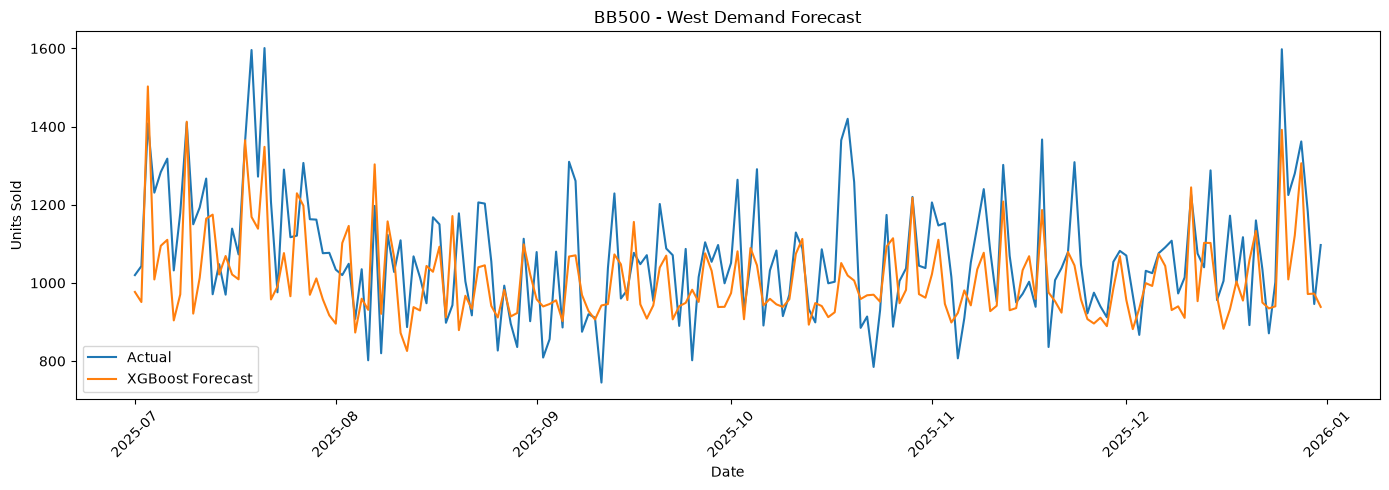

In [10]:
sample = forecasts[(forecasts["sku"] == "BB500") & (forecasts["region"] == "West")].copy()
plt.figure(figsize=(14, 5))
plt.plot(sample["date"], sample["units_sold"], label="Actual")
plt.plot(sample["date"], sample["ml_prediction"], label="XGBoost Forecast")
plt.title("BB500 - West Demand Forecast")
plt.xlabel("Date")
plt.ylabel("Units Sold")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

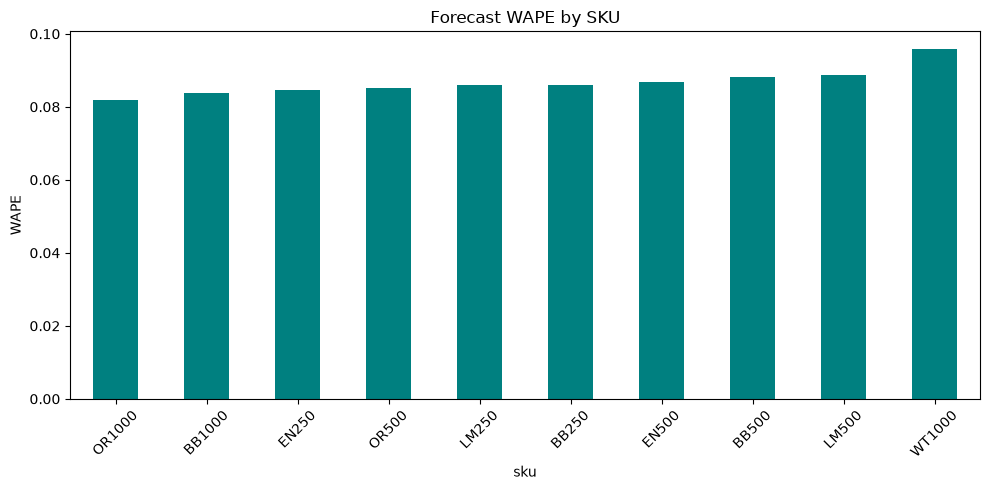

In [11]:
plt.figure(figsize=(10, 5))
performance.sort_values("WAPE").plot.bar(x="sku", y="WAPE", legend=False, ax=plt.gca(), color="teal")
plt.title("Forecast WAPE by SKU")
plt.ylabel("WAPE")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()